# Analysis of mono, co, and triculture imaging data

### Culture conditions:
- mono = EEO
- co   = EEO + ESC
- tri  = EEO + ESC + Mac

### Channels:
- 1: DAPI
- 2: pcJun
- 3: ki67
- 4: cell trace (Cy5)
- 5: EpCAM (Cy7)

### Experimental conditions:
- DMSO   = (no-stim) + DMSO
- IL-1B  = IL-1B     + DMSO
- Bent   = IL-1B     + Bentamapimod
- 3013   = IL-1B     + 3013

### Donors:
- 284
- 287
- 304

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import wilcoxon
from pingouin import rm_anova, pairwise_tests


donors = [284, 287, 304]
conditions = ['DMSO', 'IL1B', 'Bent', '3013']
cell_types = ['epithelial', 'ESC', 'macrophage']

cell_colors = {'epithelial': '#cf524e', 'ESC': '#75bbfd', 'macrophage': '#894585'}

drug_colors = ["#FFFFFF", "#858585", "#4D96FF", "#FD35C4"]
sns.set_palette(sns.color_palette(drug_colors))


def load_data(culture_type):
    df = pd.read_csv(f'data/{culture_type}_data.csv')
    df['culture_type'] = culture_type
    df = df.rename(columns={'rf_cell_type': 'cell_type'})
    df = df.drop(columns=['Unnamed: 0'])

    df['pcJun'] = df['channel_2_nuclear_mean']
    df['log_pcJun'] = np.log(df['pcJun'])

    df['ki67'] = df['channel_3_nuclear_mean']
    df['log_ki67'] = np.log(df['ki67'])

    return df

df = pd.concat([load_data(culture) for culture in ('mono', 'co', 'tri')])

# assign drug conditions based on well_id (from platemap)
condition_map = {2: 'DMSO',
                 3: 'IL1B',
                 4: 'Bent',
                 5: '3013',
                 8: 'DMSO',
                 9: 'IL1B',
                 10: 'Bent',
                 11: '3013'}

df['drug_condition'] = df['well_id'].apply(lambda well: condition_map[int(well[1:])])

# each row = 1 cell
#df.to_csv('data/all_data.csv')

### Single cell analysis

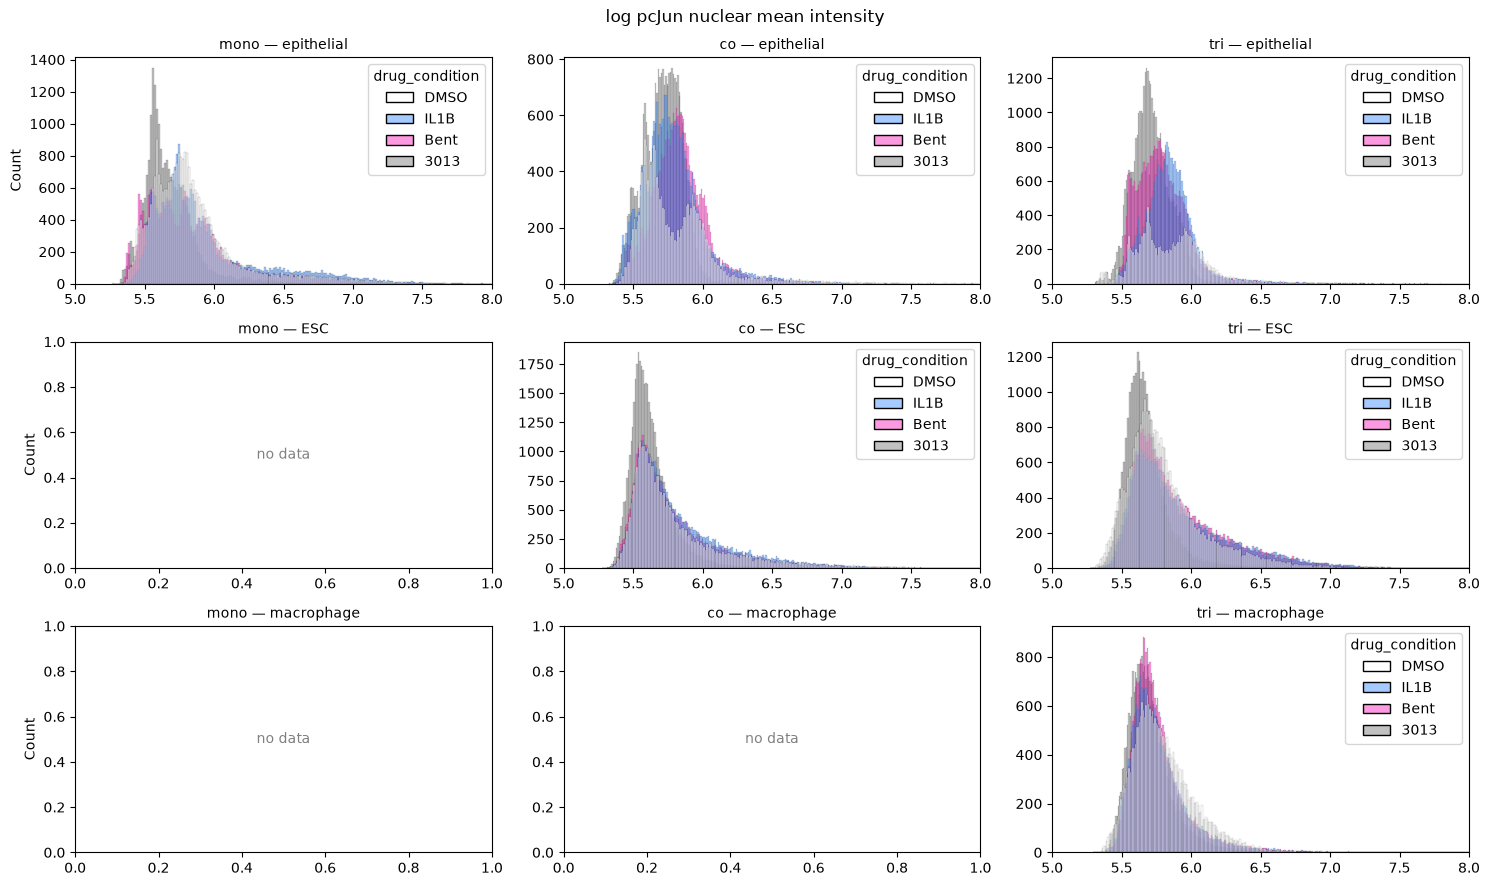

In [65]:
fig, axs = plt.subplots(3, 3, figsize=(15, 9))
cultures = ('mono', 'co', 'tri')
cells = ('epithelial', 'ESC', 'macrophage')

for i, cell in enumerate(cells):
    for j, culture in enumerate(cultures):
        ax = axs[i, j]
        mask = (df['culture_type'] == culture) & (df['cell_type'] == cell)
        data = df[mask]

        if len(data) > 0:
            sns.histplot(data, x='log_pcJun', hue='drug_condition', ax=ax, legend=True)
            ax.set_xlim(5, 8)
        else:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes, color='gray')

        ax.set_title(f'{culture} — {cell}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count' if j == 0 else '')

fig.suptitle('log pcJun nuclear mean intensity')
fig.tight_layout()

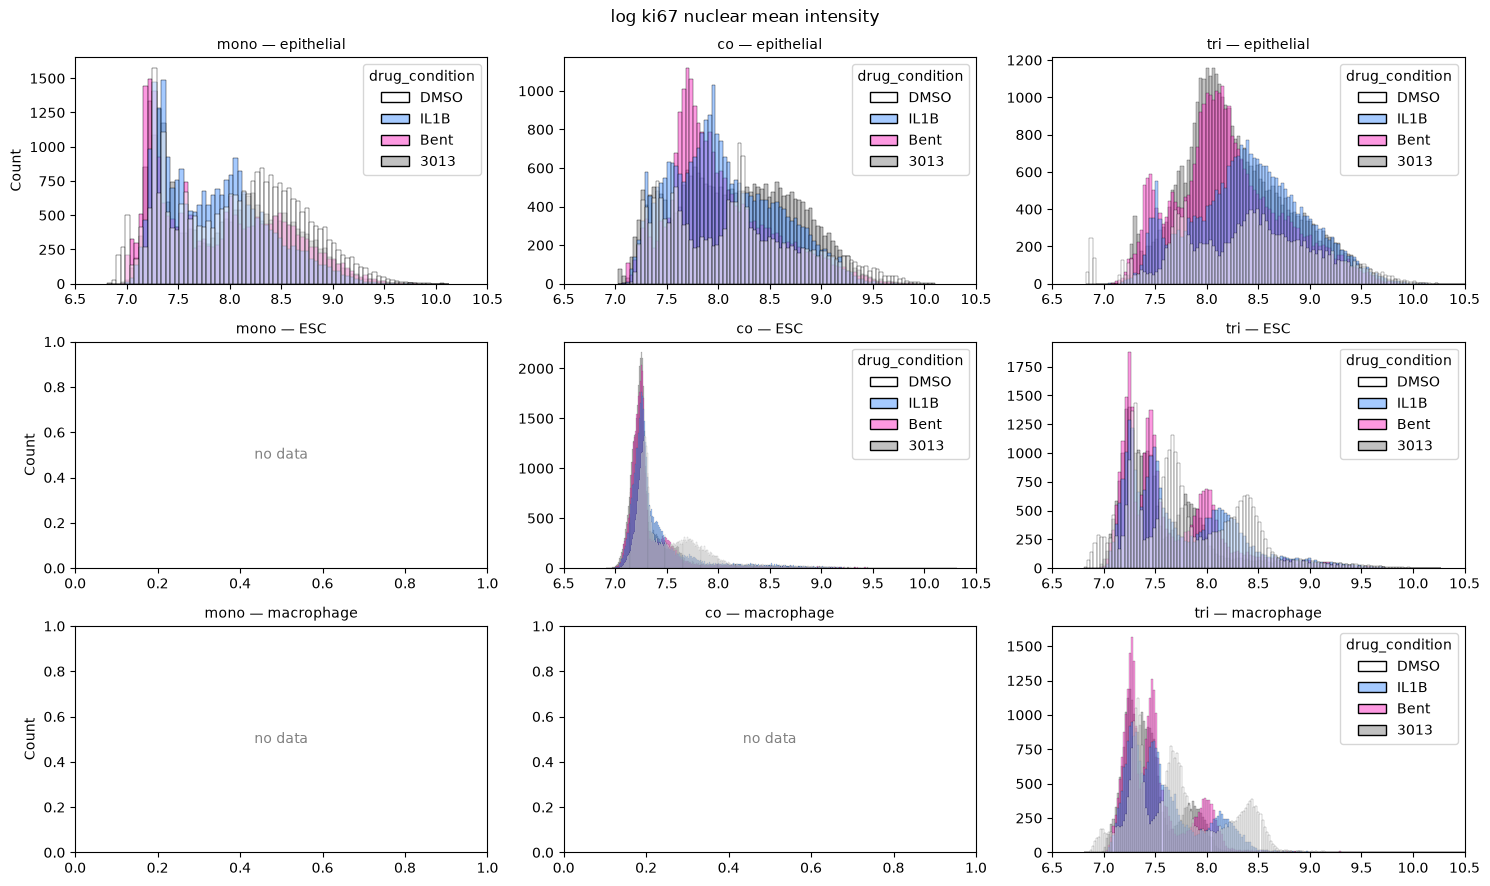

In [66]:
fig, axs = plt.subplots(3, 3, figsize=(15, 9))
cultures = ('mono', 'co', 'tri')
cells = ('epithelial', 'ESC', 'macrophage')

for i, cell in enumerate(cells):
    for j, culture in enumerate(cultures):
        ax = axs[i, j]
        mask = (df['culture_type'] == culture) & (df['cell_type'] == cell)
        data = df[mask]

        if len(data) > 0:
            sns.histplot(data, x='log_ki67', hue='drug_condition', ax=ax, legend=True)
            ax.set_xlim(6.5, 10.5)
        else:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes, color='gray')

        ax.set_title(f'{culture} — {cell}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count' if j == 0 else '')

fig.suptitle('log ki67 nuclear mean intensity')
fig.tight_layout()

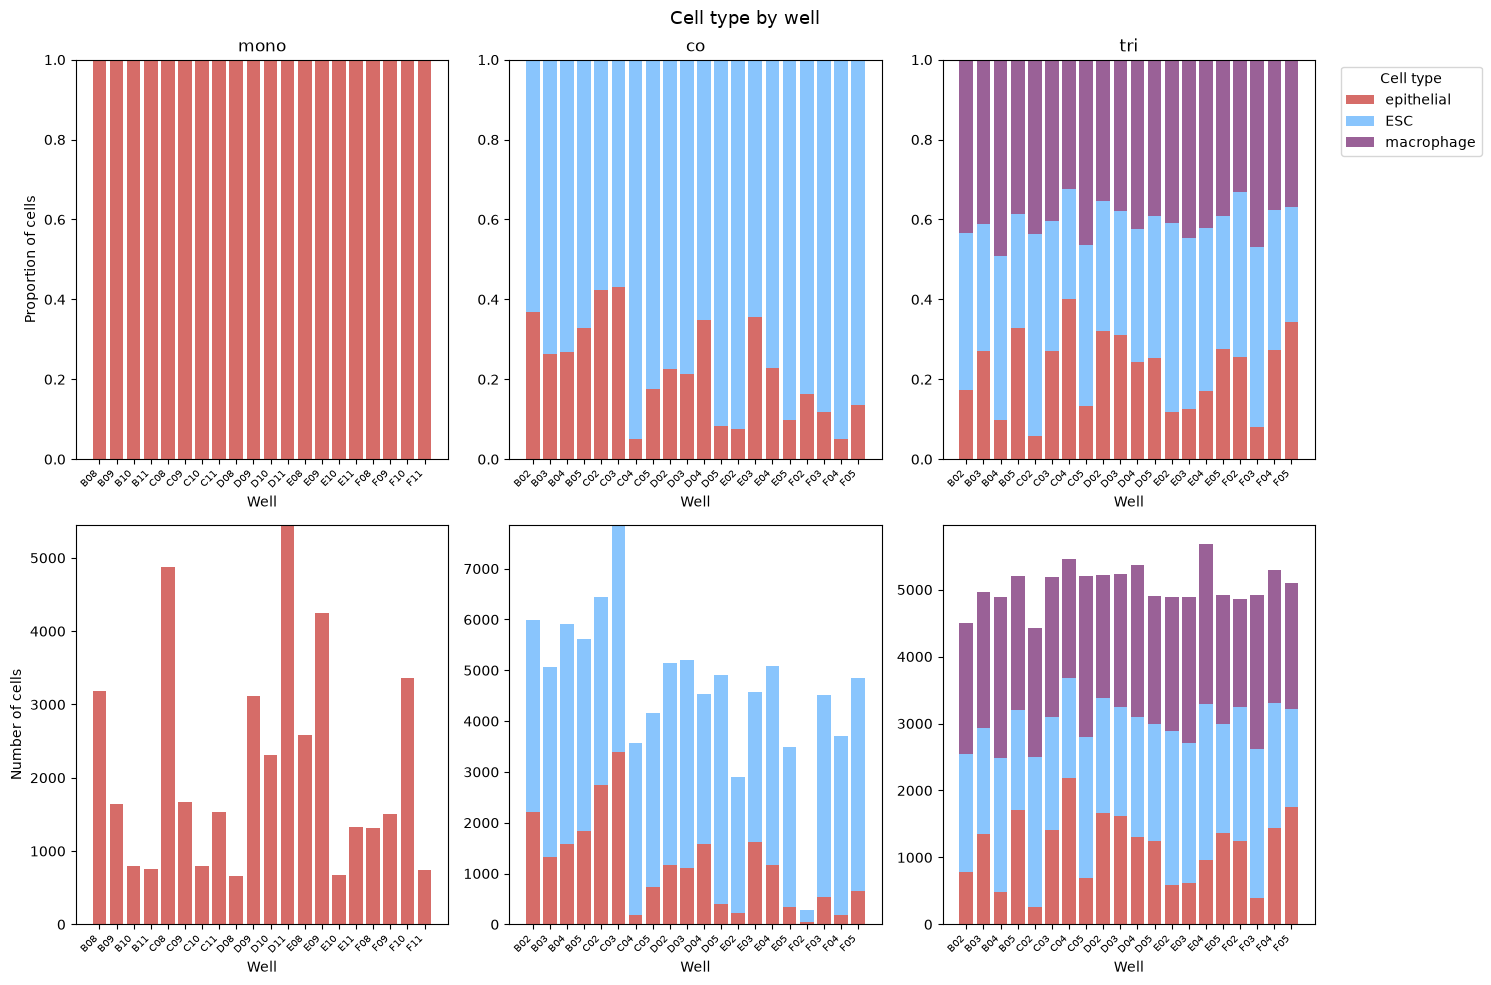

In [67]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for j, culture in enumerate(cultures):
    subset = df[(df['culture_type'] == culture) & (df['donor_id'] == 304)]

    counts = (subset.groupby(['well_id', 'cell_type'])
              .size()
              .unstack(fill_value=0))

    for ct in cell_types:
        if ct not in counts.columns:
            counts[ct] = 0
    counts = counts[cell_types]
    props = counts.div(counts.sum(axis=1), axis=0)

    for row, (data, ylabel, ylim) in enumerate([
        (props, 'Proportion of cells', (0, 1)),
        (counts, 'Number of cells', (0, None))
    ]):
        ax = axs[row, j]
        bottom = np.zeros(len(data))
        for ct in cell_types:
            ax.bar(range(len(data)), data[ct].values,
                   bottom=bottom, label=ct, color=cell_colors[ct], alpha=0.85)
            bottom += data[ct].values

        if row == 0:
            ax.set_title(culture, fontsize=12)
        ax.set_xlabel('Well')
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=7)
        if ylim[1]:
            ax.set_ylim(*ylim)
        if j == 0:
            ax.set_ylabel(ylabel)

axs[0, -1].legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Cell type by well', fontsize=13)
fig.tight_layout()

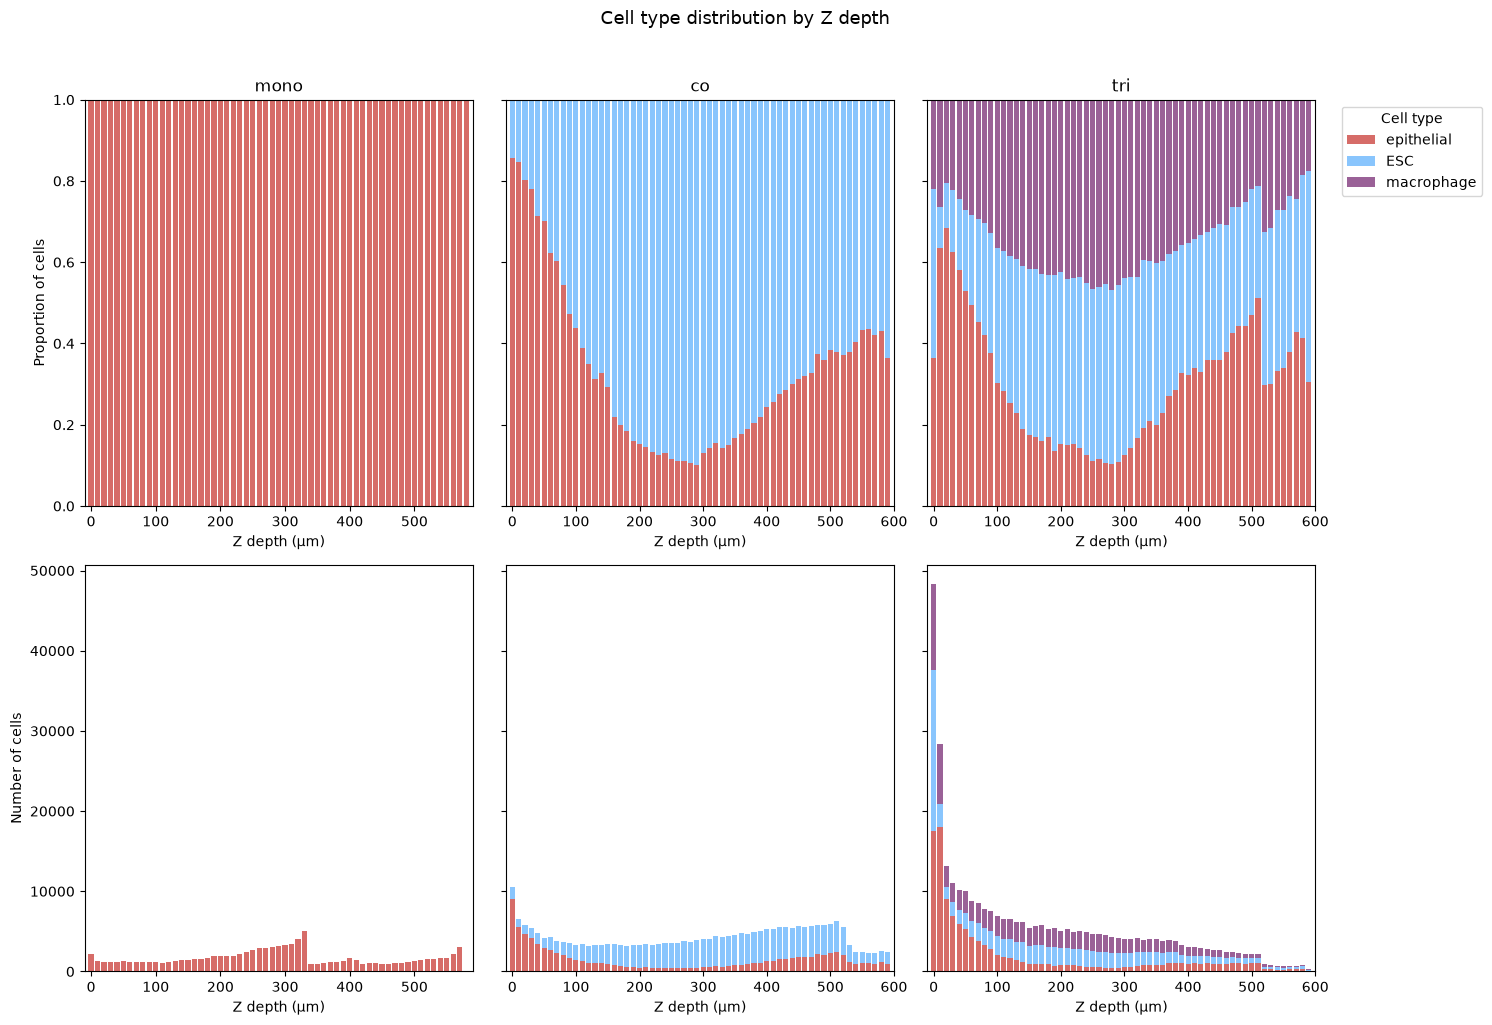

In [2]:
cultures = ['mono', 'co', 'tri']
cell_types = ['epithelial', 'ESC', 'macrophage']

# bin z depth
z_bin_size = 10  # um — adjust as needed
df['z_bin'] = (df['centroid_z_um'] // z_bin_size * z_bin_size).astype(int)

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharey='row')

for j, culture in enumerate(cultures):
    subset = df[df['culture_type'] == culture]

    counts = (subset.groupby(['z_bin', 'cell_type'])
              .size()
              .unstack(fill_value=0))

    for ct in cell_types:
        if ct not in counts.columns:
            counts[ct] = 0
    counts = counts[cell_types]
    props = counts.div(counts.sum(axis=1), axis=0)

    z_bins = counts.index.values
    bar_width = z_bin_size * 0.8

    for row, data in enumerate([props, counts]):
        ax = axs[row, j]
        bottom = np.zeros(len(z_bins))
        for ct in cell_types:
            ax.bar(z_bins, data[ct].values, width=bar_width,
                   bottom=bottom, label=ct, color=cell_colors[ct], alpha=0.85)
            bottom += data[ct].values

        ax.set_xlabel('Z depth (µm)')
        ax.set_xlim(z_bins.min() - z_bin_size, z_bins.max() + z_bin_size)
        if row == 0:
            ax.set_title(culture, fontsize=12)
            ax.set_ylim(0, 1)

axs[0, 0].set_ylabel('Proportion of cells')
axs[1, 0].set_ylabel('Number of cells')
axs[0, -1].legend(title='Cell type', bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle('Cell type distribution by Z depth', fontsize=13, y=1.02)
fig.tight_layout()

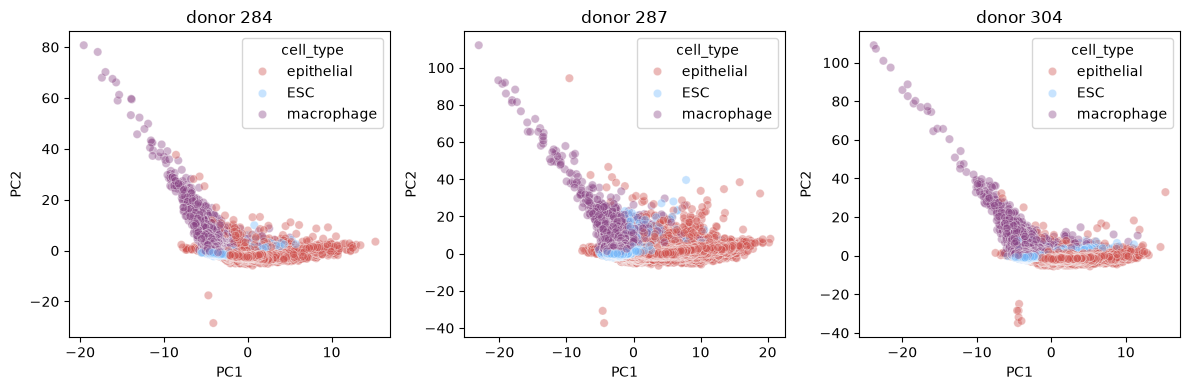

In [69]:
features = ['nuclear_volume_voxels', 'cytoplasm_volume_voxels',
       'channel_1_nuclear_mean', 'channel_1_nuclear_max',
       'channel_1_nuclear_std', 'channel_1_cytoplasm_mean',
       'channel_1_cytoplasm_max', 'channel_1_cytoplasm_std', 'channel_1_nc_ratio',
       'channel_2_nuclear_mean', 'channel_2_nuclear_max',
       'channel_2_nuclear_std', 'channel_2_cytoplasm_mean',
       'channel_2_cytoplasm_max', 'channel_2_cytoplasm_std', 'channel_2_nc_ratio',
       'channel_3_nuclear_mean', 'channel_3_nuclear_max',
       'channel_3_nuclear_std', 'channel_3_cytoplasm_mean',
       'channel_3_cytoplasm_max', 'channel_3_cytoplasm_std', 'channel_3_nc_ratio',
       'channel_4_nuclear_mean', 'channel_4_nuclear_max',
       'channel_4_nuclear_std', 'channel_4_cytoplasm_mean',
       'channel_4_cytoplasm_max', 'channel_4_cytoplasm_std', 'channel_4_nc_ratio',
       'channel_5_nuclear_mean', 'channel_5_nuclear_max',
       'channel_5_nuclear_std', 'channel_5_cytoplasm_mean',
       'channel_5_cytoplasm_max', 'channel_5_cytoplasm_std', 'channel_5_nc_ratio',
       'centroid_z', 'axis_major_length', 'axis_minor_length', 'aspect_ratio',
       'nn_dist', 'nn5_mean_dist', 'num_neighbors_within_50_um', 'sphericity',
       ]

X = df[features].dropna().to_numpy()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=components, columns=[f'PC{i}' for i in range(1, 3)])
pca_df['cell_type'] = df.dropna()['cell_type'].to_numpy()
pca_df['donor_id'] = df.dropna()['donor_id'].to_numpy()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

sns.scatterplot(pca_df[pca_df['donor_id'] == 284], x='PC1', y='PC2', hue='cell_type', palette=list(cell_colors.values()), alpha=0.4, ax=axs[0])
axs[0].set_title('donor 284')

sns.scatterplot(pca_df[pca_df['donor_id'] == 287], x='PC1', y='PC2', hue='cell_type', palette=list(cell_colors.values()), alpha=0.4, ax=axs[1])
axs[1].set_title('donor 287')

sns.scatterplot(pca_df[pca_df['donor_id'] == 304], x='PC1', y='PC2', hue='cell_type', palette=list(cell_colors.values()), alpha=0.4, ax=axs[2])
axs[2].set_title('donor 304')

fig.tight_layout()

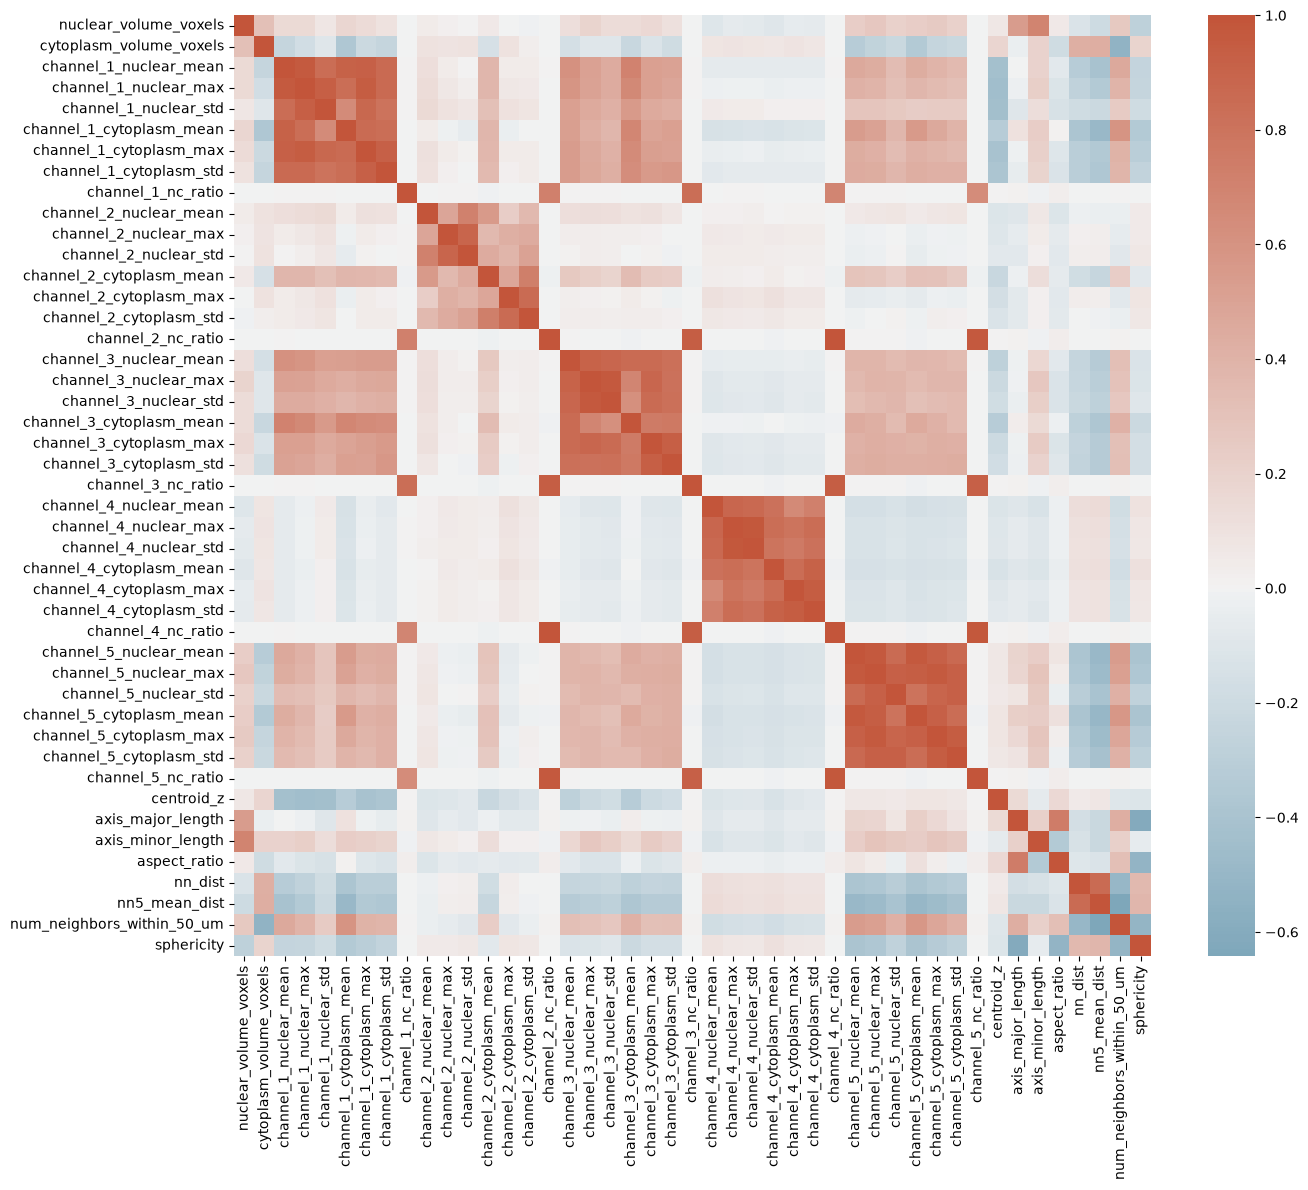

In [70]:
corr_matrix = df[features].corr()

fig, ax = plt.subplots(figsize=(14,12))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, cmap=cmap, center=0, ax=ax)

fig.tight_layout()

bruh I should make art out of correlation heatmaps. is so pretty.

### Donor-mean analysis

In [3]:
order = ['DMSO', 'IL1B', 'Bent', '3013']
df['drug_condition'] = pd.Categorical(df['drug_condition'], categories=order, ordered=True)


def boxplot(df, column, ax):
    donor_means = df.groupby(['donor_id', 'drug_condition', 'culture_type', 'cell_type'])[['pcJun', 'log_pcJun', 'ki67', 'log_ki67']].mean().reset_index()

    # boxplot (all data)
    sns.boxplot(donor_means, x='drug_condition', y=column, hue='drug_condition', order=order, hue_order=order, dodge=False, showfliers=False, legend=True, ax=ax)

    # scatterplot (donor means)
    sns.stripplot(donor_means, x='drug_condition', y=column, dodge=False, jitter=True, color='k', ax=ax)

    ax.set_xlabel('')
    ax.legend(title='', loc='upper right')


def run_anova(df, column):
    """
    Runs Repeated Measures ANOVA on all data in `df[column]`. Each measurement is a donor mean.
    """

    # --- Repeated-measures ANOVA ---
    anova_result = rm_anova(data=df, dv=column,
                            within='drug_condition', subject='donor_id')
    print("=== RM-ANOVA ===")
    print(anova_result[['Source', 'F', 'p_unc', 'ng2']].to_string(index=False))

    posthoc = pairwise_tests(data=df, dv=column,
                         within='drug_condition', subject='donor_id',
                         padjust='fdr_bh')
    print(posthoc[['A', 'B', 'T', 'p_unc', 'p_corr']].to_string(index=False))


def run_wilcoxon(df, column):
    """
    Runs paired Wilcoxon test on all data in `df[column]`. Each measurement is a donor mean.
    """

    # --- Paired Wilcoxon for specific contrasts ---
    print("\n=== Paired Wilcoxon ===")
    contrasts = [('DMSO', 'IL1B'), ('IL1B', 'Bent'), ('IL1B', '3013')]

    results = []
    for a, b in contrasts:
        vals_a = df[df['drug_condition'] == a].sort_values('donor_id')[column].values
        vals_b = df[df['drug_condition'] == b].sort_values('donor_id')[column].values
        stat, p = wilcoxon(vals_a, vals_b)
        results.append({'contrast': f'{a} vs {b}', 'stat': stat, 'p': p})

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

### Monoculture

In [321]:
mono_df = df[df['culture_type'] == 'mono']

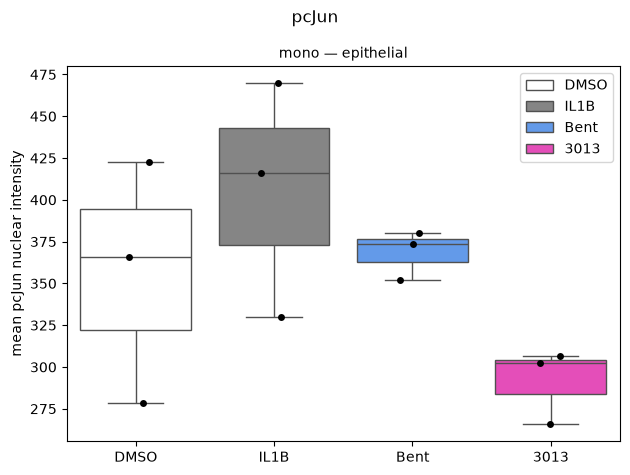

In [323]:
fig, ax = plt.subplots()

boxplot(mono_df, 'pcJun', ax)
ax.set_ylabel('mean pcJun nuclear intensity')
ax.set_title(f'mono — epithelial', fontsize=10)

fig.suptitle('pcJun')
fig.tight_layout()

In [222]:
run_anova(mono_df, 'pcJun')

=== RM-ANOVA ===
        Source        F   p_unc      ng2
drug_condition 6.561029 0.02532 0.478966
   A    B          T    p_unc   p_corr
3013 Bent -13.624445 0.005344 0.016032
3013 DMSO  -2.057091 0.175951 0.263927
3013 IL1B  -3.786257 0.063213 0.126427
Bent DMSO   0.383550 0.738245 0.738245
Bent IL1B  -1.122515 0.378300 0.453960
DMSO IL1B -42.009544 0.000566 0.003397


Fire. 3013 sees a reduction in pcJun as compared to IL-1B. Furthermore, 3013 sees a *greater* reduction in pcJun than Bent. Monoculture data suggests that 3013 works as a JNK inhibitor.

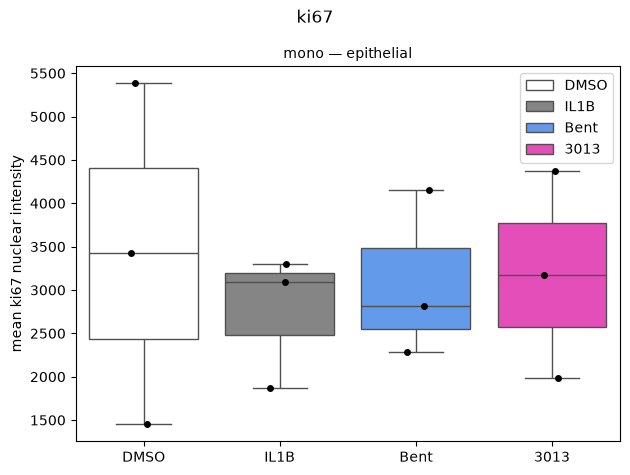

In [324]:
fig, ax = plt.subplots()

boxplot(mono_df, 'ki67', ax)
ax.set_ylabel('mean ki67 nuclear intensity')
ax.set_title(f'mono — epithelial', fontsize=10)

fig.suptitle('ki67')
fig.tight_layout()

In [296]:
run_anova(mono_df, 'ki67')

=== RM-ANOVA ===
        Source        F   p_unc      ng2
drug_condition 0.666685 0.60253 0.048009
   A    B         T    p_unc   p_corr
DMSO IL1B  0.899972 0.463117 0.691464
DMSO Bent  0.551932 0.636433 0.691464
DMSO 3013  0.550321 0.637354 0.691464
IL1B Bent -1.010169 0.418755 0.691464
IL1B 3013 -1.299372 0.323424 0.691464
Bent 3013 -0.458715 0.691464 0.691464


No diff in ki67 by any of the drug conditions.

### Coculture

In [313]:
co_df = df[df['culture_type'] == 'co']
cells = ('epithelial', 'ESC')

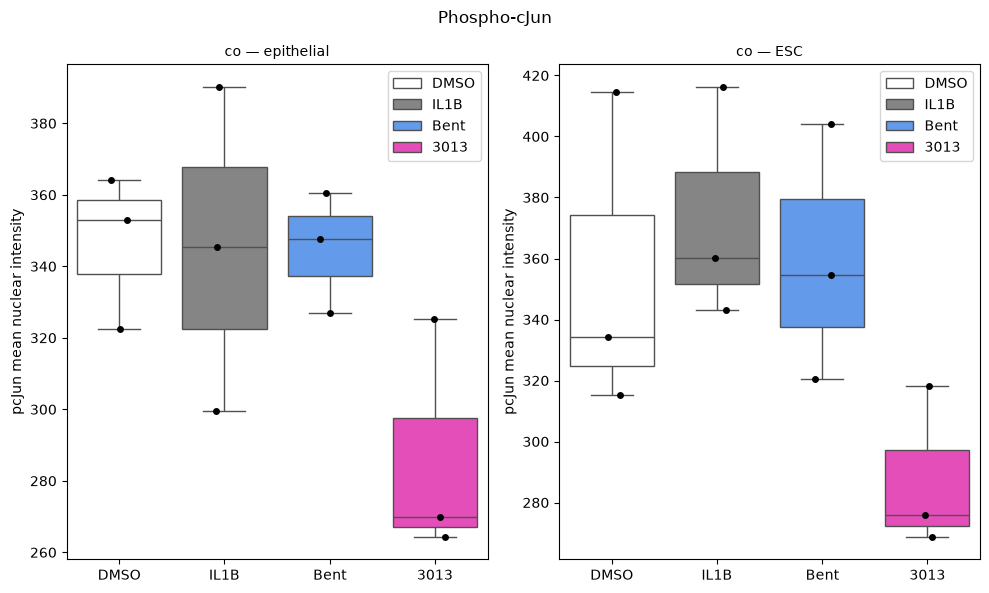

In [326]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

for cell, ax in zip(cells, axs):
    filter = co_df['cell_type'] == cell
    boxplot(co_df[filter], 'pcJun', ax)
    ax.set_title(f'co — {cell}', fontsize=10)
    ax.set_ylabel('pcJun mean nuclear intensity')

fig.suptitle('Phospho-cJun')
fig.tight_layout()

In [232]:
run_anova(co_df[co_df['cell_type'] == 'epithelial'], 'pcJun')

=== RM-ANOVA ===
        Source        F    p_unc     ng2
drug_condition 2.637552 0.144055 0.49997
   A    B         T    p_unc   p_corr
3013 Bent -4.238824 0.051402 0.266456
3013 DMSO -3.127641 0.088819 0.266456
3013 IL1B -1.736830 0.224551 0.449101
Bent DMSO -0.085739 0.939484 0.998981
Bent IL1B -0.001441 0.998981 0.998981
DMSO IL1B  0.040600 0.971303 0.998981


In [233]:
run_anova(co_df[co_df['cell_type'] == 'ESC'], 'pcJun')

=== RM-ANOVA ===
        Source        F    p_unc      ng2
drug_condition 2.865807 0.126139 0.494512
   A    B         T    p_unc   p_corr
3013 Bent -6.929759 0.020195 0.060586
3013 DMSO -1.677908 0.235367 0.470734
3013 IL1B -9.075299 0.011925 0.060586
Bent DMSO  0.100273 0.929274 0.929274
Bent IL1B -0.905163 0.460918 0.691378
DMSO IL1B -0.464735 0.687808 0.825369


In coculture, 3013 drives a reduction in pcJun in ESCs, but not in epithelial cells. This could be due to insufficient epithelial drug dosage, or it could suggest that the drug acts on ESCs faster than on epithelial cells.

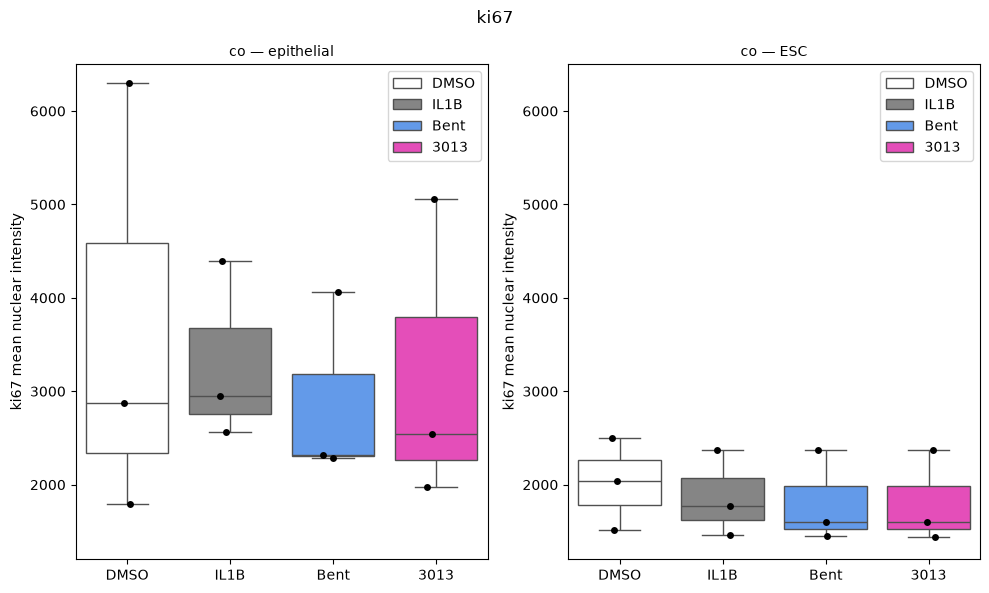

In [327]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))
cells = ('epithelial', 'ESC')

for cell, ax in zip(cells, axs):
    filter = co_df['cell_type'] == cell
    boxplot(co_df[filter], 'ki67', ax)
    ax.set_title(f'co — {cell}', fontsize=10)
    ax.set_ylabel('ki67 mean nuclear intensity')
    ax.set_ylim(1200, 6500)

fig.suptitle('ki67')
fig.tight_layout()

### Triculture

In [260]:
tri_df = df[df['culture_type'] == 'tri']
cells = ('epithelial', 'ESC', 'macrophage')

C:\Users\jaked\AppData\Local\Temp\ipykernel_21252\2433443968.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y=column, hue='drug_condition', dodge=False, jitter=True, color='k', ax=ax)
C:\Users\jaked\AppData\Local\Temp\ipykernel_21252\2433443968.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y=column, hue='drug_condition', dodge=False, jitter=True, color='k', ax=ax)
C:\Users\jaked\AppData\Local\Temp\ipykernel_21252\2433443968.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y=column, hue='drug_condition', dodge=False, jitter=T

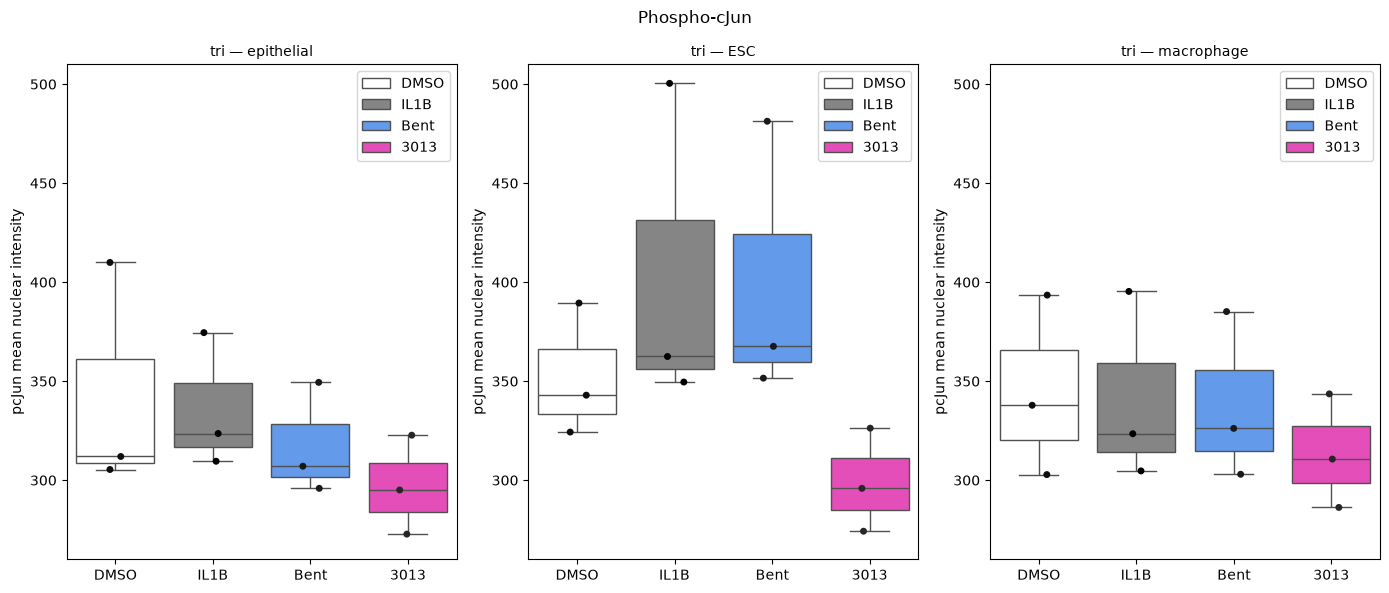

In [261]:
fig, axs = plt.subplots(1, 3, figsize=(14,6))

for cell, ax in zip(cells, axs):
    filter = tri_df['cell_type'] == cell
    boxplot(tri_df[filter], 'pcJun', ax)
    ax.set_title(f'tri — {cell}', fontsize=10)
    ax.set_ylabel('pcJun mean nuclear intensity')
    ax.set_ylim(260, 510)

fig.suptitle('Phospho-cJun')
fig.tight_layout()

In [173]:
run_anova(tri_df[tri_df['cell_type'] == 'epithelial'], 'pcJun')

=== RM-ANOVA ===
        Source        F    p_unc     ng2
drug_condition 3.875172 0.074396 0.23865
   A    B         T    p_unc   p_corr
3013 Bent -2.035712 0.178729 0.268611
3013 DMSO -2.033089 0.179074 0.268611
3013 IL1B -3.183197 0.086131 0.258393
Bent DMSO -1.400532 0.296338 0.355606
Bent IL1B -5.354885 0.033150 0.198897
DMSO IL1B  0.449060 0.697358 0.697358


In [174]:
run_anova(tri_df[tri_df['cell_type'] == 'ESC'], 'pcJun')

=== RM-ANOVA ===
        Source        F    p_unc      ng2
drug_condition 8.726796 0.013147 0.442669
   A    B          T    p_unc   p_corr
3013 Bent  -3.770914 0.063681 0.184960
3013 DMSO -10.795291 0.008472 0.050832
3013 IL1B  -3.055713 0.092480 0.184960
Bent DMSO   2.180980 0.160955 0.241433
Bent IL1B  -0.526605 0.651042 0.651042
DMSO IL1B  -1.756461 0.221092 0.265310


Why might we see a more drastic drop in pcJun in monoculture vs. triculture due to 3013?
- ESCs and macrophages pick up 3013 -> lower effective epithelial 3013 dose -> smaller magnitude effect

C:\Users\jaked\AppData\Local\Temp\ipykernel_21252\2433443968.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y=column, hue='drug_condition', dodge=False, jitter=True, color='k', ax=ax)
C:\Users\jaked\AppData\Local\Temp\ipykernel_21252\2433443968.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y=column, hue='drug_condition', dodge=False, jitter=True, color='k', ax=ax)
C:\Users\jaked\AppData\Local\Temp\ipykernel_21252\2433443968.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y=column, hue='drug_condition', dodge=False, jitter=T

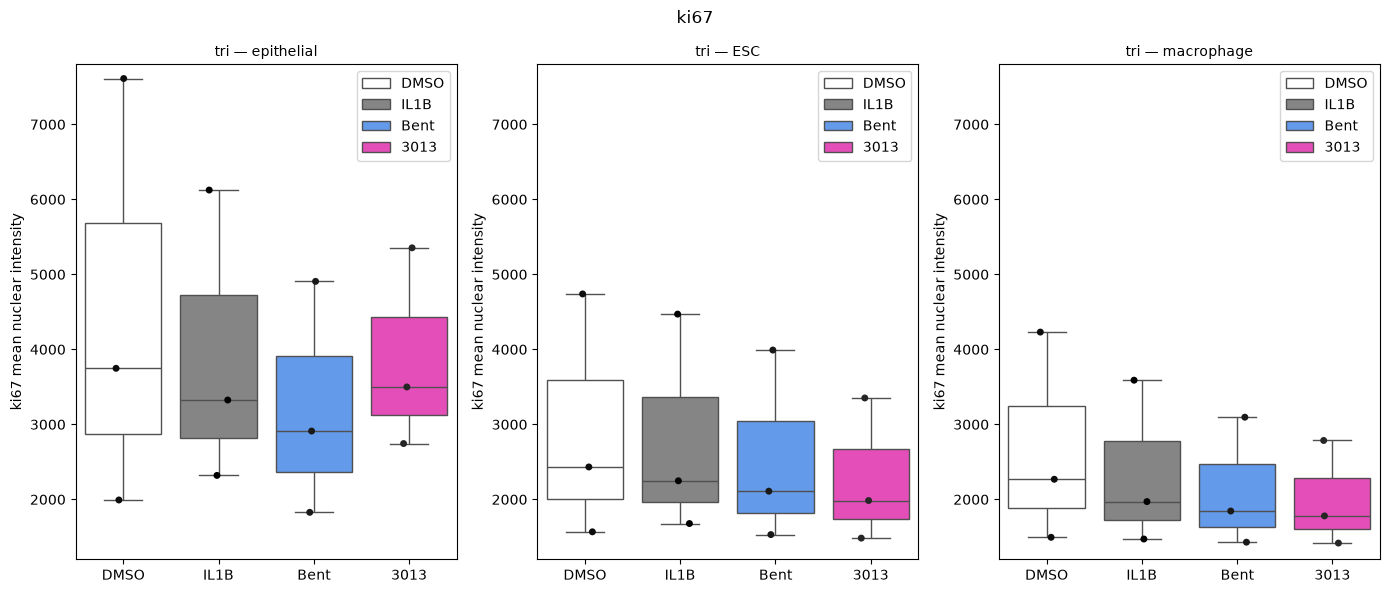

In [262]:
fig, axs = plt.subplots(1, 3, figsize=(14,6))

for cell, ax in zip(cells, axs):
    filter = tri_df['cell_type'] == cell
    boxplot(tri_df[filter], 'ki67', ax)
    ax.set_title(f'tri — {cell}', fontsize=10)
    ax.set_ylabel('ki67 mean nuclear intensity')
    ax.set_ylim(1200, 7800)

fig.suptitle('ki67')
fig.tight_layout()

### Epithelial growth

C:\Users\jaked\AppData\Local\Temp\ipykernel_36264\55104184.py:5: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(donor_means, x='drug_condition', y='ki67', order=order,
C:\Users\jaked\AppData\Local\Temp\ipykernel_36264\55104184.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y='ki67', order=order,


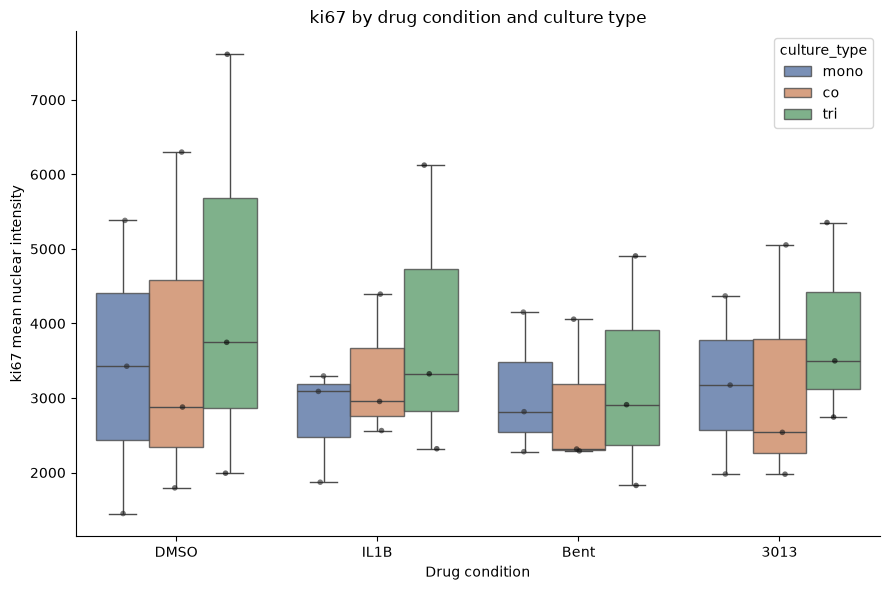

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

donor_means = df[df['cell_type'] == 'epithelial'].groupby(['donor_id', 'drug_condition', 'culture_type'])[['ki67']].mean().reset_index()

sns.boxplot(donor_means, x='drug_condition', y='ki67', order=order,
            hue='culture_type', hue_order=cultures, showfliers=False,
            boxprops=dict(alpha=0.8), palette=sns.color_palette('deep'), ax=ax)

sns.stripplot(donor_means, x='drug_condition', y='ki67', order=order,
              hue='culture_type', hue_order=cultures, dodge=True, jitter=True,
              color='k', size=4, alpha=0.6, legend=False, ax=ax)

ax.set_xlabel('Drug condition')
ax.set_ylabel('ki67 mean nuclear intensity')
ax.set_title('ki67 by drug condition and culture type')

sns.despine()
plt.tight_layout()
plt.show()